# Recipe Recommendation System: EDA

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Read the raw datasets
raw_recipes_df = pd.read_csv('RAW_recipes.csv')
raw_users_df = pd.read_csv('RAW_interactions.csv')

In [3]:
# Shape of the data
print('The shape of the recipe dataset is:', raw_recipes_df.shape)
print('The shape of the user interactions dataset is:', raw_users_df.shape)

The shape of the recipe dataset is: (231637, 12)
The shape of the user interactions dataset is: (1132367, 5)


In [4]:
# View recipes dataset
raw_recipes_df.head()

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13
3,alouette potatoes,59389,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...","[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"['weeknight', 'time-to-make', 'course', 'main-...","[352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8


In [5]:

raw_users_df.head()

,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall..."
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...
3,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...
4,57222,85009,2011-10-01,5,"Made the cheddar bacon topping, adding a sprin..."


##  Data Cleaning <a class="anchor" id="three"></a>

In [6]:
# Info about the recipe dataset
raw_recipes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231637 entries, 0 to 231636
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   name            231636 non-null  object
 1   id              231637 non-null  int64 
 2   minutes         231637 non-null  int64 
 3   contributor_id  231637 non-null  int64 
 4   submitted       231637 non-null  object
 5   tags            231637 non-null  object
 6   nutrition       231637 non-null  object
 7   n_steps         231637 non-null  int64 
 8   steps           231637 non-null  object
 9   description     226658 non-null  object
 10  ingredients     231637 non-null  object
 11  n_ingredients   231637 non-null  int64 
dtypes: int64(5), object(7)
memory usage: 21.2+ MB


In [7]:
# Convert 'id' and 'contributor_id' columns to object data type
raw_recipes_df['id'] = raw_recipes_df['id'].astype(str)
raw_recipes_df['contributor_id'] = raw_recipes_df['contributor_id'].astype(str)

# Convert 'submitted' column to date data type
raw_recipes_df['submitted'] = pd.to_datetime(raw_recipes_df['submitted'], format='%Y-%m-%d')

# Print updated data types of the columns
raw_recipes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231637 entries, 0 to 231636
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   name            231636 non-null  object        
 1   id              231637 non-null  object        
 2   minutes         231637 non-null  int64         
 3   contributor_id  231637 non-null  object        
 4   submitted       231637 non-null  datetime64[ns]
 5   tags            231637 non-null  object        
 6   nutrition       231637 non-null  object        
 7   n_steps         231637 non-null  int64         
 8   steps           231637 non-null  object        
 9   description     226658 non-null  object        
 10  ingredients     231637 non-null  object        
 11  n_ingredients   231637 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(8)
memory usage: 21.2+ MB


In [8]:
# Info about the recipe dataset
raw_users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1132367 entries, 0 to 1132366
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   user_id    1132367 non-null  int64 
 1   recipe_id  1132367 non-null  int64 
 2   date       1132367 non-null  object
 3   rating     1132367 non-null  int64 
 4   review     1132198 non-null  object
dtypes: int64(3), object(2)
memory usage: 43.2+ MB


In [9]:
# Convert 'user_id' and 'recipe_id' columns to object data type
raw_users_df['user_id'] = raw_users_df['user_id'].astype(str)
raw_users_df['recipe_id'] = raw_users_df['recipe_id'].astype(str)

# Convert 'submitted' column to date data type
raw_users_df['date'] = pd.to_datetime(raw_users_df['date'], format='%Y-%m-%d')

# Print updated data types of the columns
raw_users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1132367 entries, 0 to 1132366
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype         
---  ------     --------------    -----         
 0   user_id    1132367 non-null  object        
 1   recipe_id  1132367 non-null  object        
 2   date       1132367 non-null  datetime64[ns]
 3   rating     1132367 non-null  int64         
 4   review     1132198 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 43.2+ MB


In [10]:
# Checking for missing values
raw_recipes_df.isna().sum()

name                 1
id                   0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
description       4979
ingredients          0
n_ingredients        0
dtype: int64

In [11]:
# Row with missing name
raw_recipes_df[raw_recipes_df['name'].isna()]

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
721,NaN,368257,10,779451,2009-04-27,"['15-minutes-or-less', 'time-to-make', 'course...","[1596.2, 249.0, 155.0, 0.0, 2.0, 112.0, 14.0]",6,"['in a bowl , combine ingredients except for o...",-------------,"['lemon', 'honey', 'horseradish mustard', 'gar...",10


In [12]:
# Drop row with missing name
raw_recipes_df.dropna(subset=['name'], inplace=True)

In [13]:
# Sanity check
raw_recipes_df.isna().sum()

name                 0
id                   0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
description       4979
ingredients          0
n_ingredients        0
dtype: int64

In [14]:
# Row with missing description
raw_recipes_df[raw_recipes_df['description'].isna()].sample(10)

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
188707,slow cooked southwestern pork stew,63114,615,32772,2003-05-27,"['weeknight', 'time-to-make', 'course', 'prepa...","[313.7, 11.0, 2.0, 29.0, 63.0, 12.0, 10.0]",8,['place chopped onion and garlic in the bottom...,NaN,"['onion', 'garlic', 'boneless pork top loin', ...",11
170551,ranch round steak,7057,100,87236,2000-03-06,"['weeknight', 'time-to-make', 'main-ingredient...","[75.1, 10.0, 1.0, 19.0, 1.0, 8.0, 1.0]",15,"['trim excess fat from meat', 'slash edges to ...",NaN,"['beef round steak', 'flour', 'dry mustard', '...",8
231113,zucchini cilantro dip,4636,15,1939,1999-11-17,"['15-minutes-or-less', 'time-to-make', 'course...","[745.3, 68.0, 47.0, 31.0, 40.0, 30.0, 25.0]",13,['line a large baking sheet with a clean dish ...,NaN,"['zucchini', 'garbanzo beans', 'cilantro leaf'...",7
13609,baked brown rice tuna casserole,5030,30,1533,1999-11-28,"['30-minutes-or-less', 'time-to-make', 'course...","[482.0, 15.0, 7.0, 4.0, 47.0, 16.0, 24.0]",7,"['saute celery in butter until tender crisp', ...",NaN,"['basmati rice', 'celery', 'butter', 'tuna', '...",8
62546,creamy cherry smoothie,30024,5,37636,2002-05-31,"['15-minutes-or-less', 'time-to-make', 'course...","[186.2, 0.0, 137.0, 2.0, 10.0, 0.0, 14.0]",2,['process all ingredients in blender until smo...,NaN,"['banana', 'dark sweet cherry', 'apple juice',...",4
72961,double chocolate banana muffins,9327,0,6357,2001-06-04,"['15-minutes-or-less', 'time-to-make', 'course...","[403.4, 25.0, 159.0, 13.0, 9.0, 27.0, 21.0]",6,"['in a large bowl , combine the first six ingr...",NaN,"['flour', 'sugar', 'baking cocoa', 'baking sod...",10
9764,asparagus chicken almonds,32001,24,1533,2002-06-24,"['30-minutes-or-less', 'time-to-make', 'course...","[337.7, 29.0, 8.0, 46.0, 59.0, 20.0, 2.0]",6,['heat oil in a heavy nonstick skillet or wok ...,NaN,"['boneless chicken breast', 'oil', 'ginger', '...",10
192047,south american peanut pork,55616,55,68807,2003-03-05,"['60-minutes-or-less', 'time-to-make', 'course...","[703.8, 71.0, 58.0, 29.0, 93.0, 49.0, 10.0]",8,"['heat olive oil over medium heat', 'add garli...",NaN,"['peanut butter', 'virgin olive oil', 'garlic'...",13
202338,stuffed yellow squash,2983,0,56112,1999-08-18,"['15-minutes-or-less', 'time-to-make', 'course...","[2256.8, 218.0, 242.0, 107.0, 208.0, 190.0, 52.0]",9,"['melt margarine in frying pan , add rice , sa...",NaN,"['yellow squash', 'raw rice', 'salt', 'pepper'...",8
15906,balsamic roasted pumpkin,37541,50,163112,2002-08-19,"['60-minutes-or-less', 'time-to-make', 'course...","[394.6, 36.0, 100.0, 9.0, 7.0, 74.0, 15.0]",10,"['peel and slice the pumpkin into 1"" cubes', '...",NaN,"['sugar pumpkin', 'butter', 'fresh sage', 'sal...",8


In [15]:
print('Missing values make up', round(raw_recipes_df.isna().sum().sum()/raw_recipes_df.shape[0]*100, 2), "%", "of the overall data.")

Missing values make up 2.15 % of the overall data.


In [16]:
# Drop rows with missing description
raw_recipes_df.dropna(subset=['description'], inplace=True)

In [17]:
# Sanity check
raw_recipes_df.isna().sum()

name              0
id                0
minutes           0
contributor_id    0
submitted         0
tags              0
nutrition         0
n_steps           0
steps             0
description       0
ingredients       0
n_ingredients     0
dtype: int64

In [18]:
raw_users_df.isna().sum()

user_id        0
recipe_id      0
date           0
rating         0
review       169
dtype: int64

In [19]:
print('Missing values make up', round(raw_users_df.isna().sum().sum()/raw_users_df.shape[0]*100, 2), "%", "of the overall data.")

Missing values make up 0.01 % of the overall data.


In [20]:
# Drop rows with missing description
raw_users_df.dropna(subset=['review'], inplace=True)

In [21]:
# Sanity check
raw_users_df.isna().sum()

user_id      0
recipe_id    0
date         0
rating       0
review       0
dtype: int64

###  Duplicate Data <a class="anchor" id="threethree"></a>

In [22]:
# Duplicated rows
print("duplicated rows in recipes dataset:", raw_recipes_df.duplicated().sum())
print("duplicated rows in user interactions dataset:", raw_users_df.duplicated().sum())

duplicated rows in recipes dataset: 0
duplicated rows in user interactions dataset: 0


Great! It appears that there are no duplicated rows within the datasets.

###  Outliers <a class="anchor" id="threefour"></a>

In [23]:
# Summary statistics of recipes dataset
raw_recipes_df.describe()

,minutes,submitted,n_steps,n_ingredients
count,2.266570e+05,226657,226657.000000,226657.000000
mean,9.602472e+03,2006-12-22 20:53:20.176478208,9.773927,9.054170
min,0.000000e+00,1999-08-06 00:00:00,0.000000,1.000000
25%,2.000000e+01,2004-12-08 00:00:00,6.000000,6.000000
50%,4.000000e+01,2007-02-17 00:00:00,9.000000,9.000000
75%,6.500000e+01,2008-11-11 00:00:00,12.000000,11.000000
max,2.147484e+09,2018-12-04 00:00:00,145.000000,43.000000
std,4.510715e+06,NaN,5.999824,3.740942


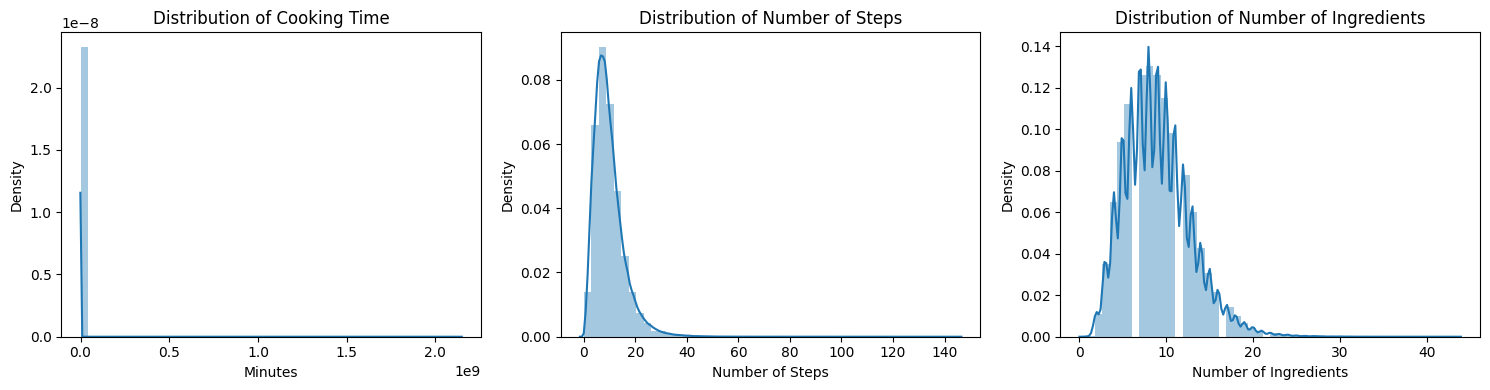

In [24]:

# Distribution
# Create a figure with three subplots
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Plot distribution of 'minutes' on the first subplot
sns.distplot(raw_recipes_df["minutes"], ax=ax[0])
ax[0].set_xlabel('Minutes')
ax[0].set_ylabel('Density')
ax[0].set_title('Distribution of Cooking Time')

# Plot distribution of 'n_steps' on the second subplot
sns.distplot(raw_recipes_df["n_steps"], ax=ax[1])
ax[1].set_xlabel('Number of Steps')
ax[1].set_ylabel('Density')
ax[1].set_title('Distribution of Number of Steps')

# Plot distribution of 'n_ingredients' on the third subplot
sns.distplot(raw_recipes_df["n_ingredients"], ax=ax[2])
ax[2].set_xlabel('Number of Ingredients')
ax[2].set_ylabel('Density')
ax[2].set_title('Distribution of Number of Ingredients')

plt.tight_layout()
plt.show()

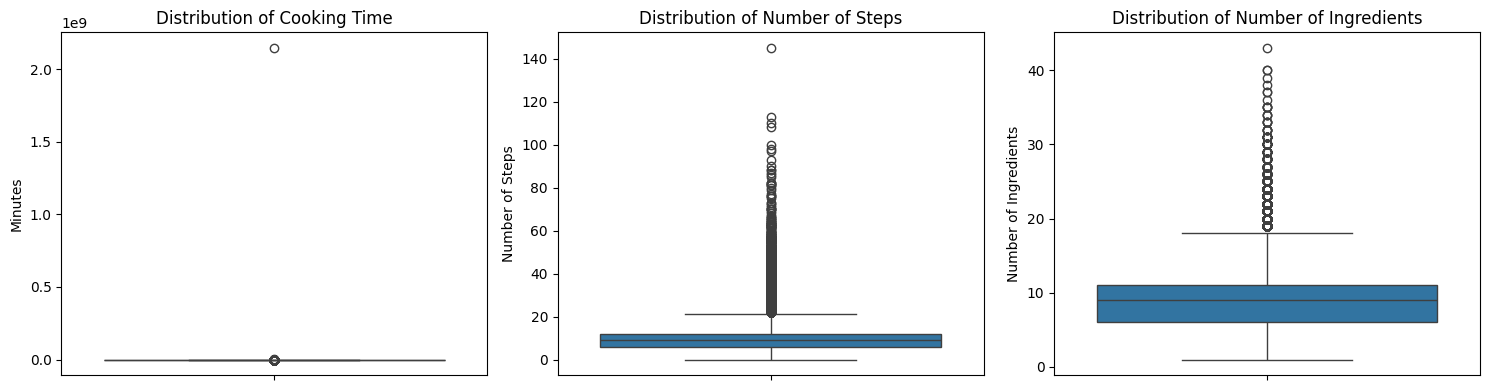

In [25]:
# Boxplots
# Create a figure with three subplots
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Plot boxplot of 'minutes' on the first subplot
sns.boxplot(data=raw_recipes_df["minutes"], ax=ax[0])
ax[0].set_ylabel('Minutes')
ax[0].set_title('Distribution of Cooking Time')

# Plot boxplot of 'n_steps' on the second subplot
sns.boxplot(data=raw_recipes_df["n_steps"], ax=ax[1])
ax[1].set_ylabel('Number of Steps')
ax[1].set_title('Distribution of Number of Steps')

# Plot boxplot of 'n_ingredients' on the third subplot
sns.boxplot(data=raw_recipes_df["n_ingredients"], ax=ax[2])
ax[2].set_ylabel('Number of Ingredients')
ax[2].set_title('Distribution of Number of Ingredients')

plt.tight_layout()
plt.show()

In [26]:
# Cooking time
# Calculate the first quartile, third quartile and the interquartile range
Q1 = raw_recipes_df['minutes'].quantile(0.25)
Q3 = raw_recipes_df['minutes'].quantile(0.75)
IQR = Q3 - Q1

# Calculate the maximum value and minimum values according to the Tukey rule
max_value = Q3 + 1.5 * IQR
min_value = Q1 - 1.5 * IQR

# Filter the data for values that are greater than max_value or less than min_value
minutes_outliers = raw_recipes_df[(raw_recipes_df['minutes'] > max_value) | (raw_recipes_df['minutes'] < min_value)]
minutes_outliers.sort_values('minutes')

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
206778,sweet rice pudding,454411,133,1889545,2011-04-25,"['time-to-make', 'course', 'main-ingredient', ...","[338.6, 12.0, 185.0, 3.0, 16.0, 20.0, 19.0]",23,"['place the rice in a medium-sized bowl', 'fil...",this is a traditional recipe from india and it...,"['basmati rice', 'whole milk', 'granulated sug...",7
204465,super soft bread machine rolls with wheat germ,210241,133,260718,2007-02-09,"['time-to-make', 'course', 'main-ingredient', ...","[1580.3, 93.0, 106.0, 92.0, 83.0, 171.0, 71.0]",7,"['in bread machine pan , put in the following ...",this recipe is adapted from the buttery bread ...,"['milk', 'vanilla essence', 'butter', 'sugar',...",9
94271,gooey butter cookies,34390,133,43121,2002-07-16,"['weeknight', 'time-to-make', 'course', 'prepa...","[163.3, 14.0, 49.0, 8.0, 3.0, 23.0, 5.0]",8,"['cream together cream cheese and butter', 'ad...",so easy to make and always a hit!,"['cream cheese', 'butter', 'egg', 'vanilla', '...",6
99018,grilled halibut with lemon tarragon mustard,116898,134,39547,2005-04-12,"['time-to-make', 'course', 'main-ingredient', ...","[470.1, 23.0, 2.0, 16.0, 153.0, 12.0, 1.0]",8,['in a small bowl whisk together the lemon jui...,"adapted from a recipe in ""the taste of summer""...","['fresh lemon juice', 'lemon, zest of', 'dijon...",9
183119,sea bass with citrus and soy,23101,134,8688,2002-03-21,"['weeknight', 'time-to-make', 'course', 'main-...","[275.1, 16.0, 24.0, 60.0, 69.0, 9.0, 3.0]",14,"['mix first 6 ingredients in 8x8x2"" glass baki...","simple, elegant and healthy, too! what more ca...","['pineapple juice', 'orange juice', 'soy sauce...",8
...,...,...,...,...,...,...,...,...,...,...,...,...
106963,homemade vanilla,425681,259205,28177,2010-05-16,"['time-to-make', 'preparation', '5-ingredients...","[69.4, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",9,['slice the vanilla beans length-wise and scra...,found this recipe on tammy's blog (http://www....,"['vanilla beans', 'vodka']",2
38116,celtic druid s honey mead meade metheglin,216215,259260,242729,2007-03-11,"['time-to-make', 'course', 'main-ingredient', ...","[531.0, 0.0, 561.0, 1.0, 1.0, 0.0, 47.0]",18,"['equipement:', 'very large pan - to hold 12 p...","mead, made from fermented honey, was the earli...","['gingerroot', 'lemons, juice and rind of', 'w...",7
106563,homemade fruit liquers,291571,288000,553251,2008-03-12,"['time-to-make', 'course', 'main-ingredient', ...","[836.2, 0.0, 333.0, 0.0, 0.0, 0.0, 27.0]",12,"['rinse the fruit or berries , fruit must be c...",this should be a nice easy project for those w...,"['berries', 'vodka', 'granulated sugar']",3
109624,how to preserve a husband,447963,1051200,576273,2011-02-01,"['time-to-make', 'course', 'preparation', 'for...","[407.4, 57.0, 50.0, 1.0, 7.0, 115.0, 5.0]",9,"['be careful in your selection', ""don't choose...","found this in a local wyoming cookbook ""a coll...","['cream', 'peach']",2


In [27]:
# Replace thie cooking time with 25 minutes
raw_recipes_df.loc[raw_recipes_df['id'] == '261647', 'minutes'] = 25

# Check value
raw_recipes_df[raw_recipes_df['id'] == '261647']

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
144074,no bake granola balls,261647,25,464080,2007-10-26,"['60-minutes-or-less', 'time-to-make', 'course...","[330.3, 23.0, 110.0, 4.0, 15.0, 24.0, 15.0]",9,"['preheat the oven to 350 degrees', 'spread oa...",healthy snacks that kids (and grown ups) will ...,"['rolled oats', 'unsweetened dried shredded co...",8


In [28]:
# Remove row
raw_recipes_df = raw_recipes_df[raw_recipes_df['id'] != '447963']

In [29]:
# Sanity check
raw_recipes_df.sort_values('minutes', ascending=True).tail()

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
5497,angelica liqueur,70551,201610,59064,2003-09-04,"['weeknight', 'time-to-make', 'course', 'cuisi...","[891.8, 0.0, 906.0, 0.0, 1.0, 0.0, 76.0]",7,"['crush the fennel , aniseed , coriander seeds...",finish off a large meal with a tiny glass of t...,"['fennel seed', 'anise seed', 'coriander seeds...",7
155044,peach brandy,98912,216015,34146,2004-09-01,"['time-to-make', 'course', 'main-ingredient', ...","[3645.3, 3.0, 2040.0, 0.0, 16.0, 0.0, 173.0]",9,"['use only fully ripened , unblemished fruit',...",posted in reply to a message board request for,"['fresh peaches', 'granulated sugar', 'honey',...",4
106963,homemade vanilla,425681,259205,28177,2010-05-16,"['time-to-make', 'preparation', '5-ingredients...","[69.4, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",9,['slice the vanilla beans length-wise and scra...,found this recipe on tammy's blog (http://www....,"['vanilla beans', 'vodka']",2
38116,celtic druid s honey mead meade metheglin,216215,259260,242729,2007-03-11,"['time-to-make', 'course', 'main-ingredient', ...","[531.0, 0.0, 561.0, 1.0, 1.0, 0.0, 47.0]",18,"['equipement:', 'very large pan - to hold 12 p...","mead, made from fermented honey, was the earli...","['gingerroot', 'lemons, juice and rind of', 'w...",7
106563,homemade fruit liquers,291571,288000,553251,2008-03-12,"['time-to-make', 'course', 'main-ingredient', ...","[836.2, 0.0, 333.0, 0.0, 0.0, 0.0, 27.0]",12,"['rinse the fruit or berries , fruit must be c...",this should be a nice easy project for those w...,"['berries', 'vodka', 'granulated sugar']",3


Having addressed the outliers in cooking time, let us now shift our focus to the number of steps involved in each recipe.

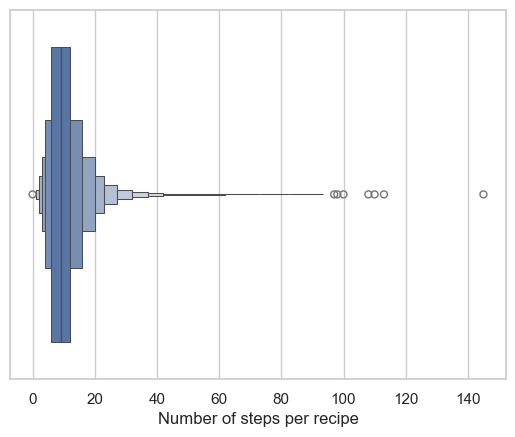

In [30]:
# Visualize boxen plot
sns.set(style = "whitegrid")
ax = sns.boxenplot(x = raw_recipes_df['n_steps'])
ax.set_xlabel('Number of steps per recipe')
plt.show()

In [31]:
# Number of steps
# Calculate the first quartile, third quartile and the interquartile range
Q1 = raw_recipes_df['n_steps'].quantile(0.25)
Q3 = raw_recipes_df['n_steps'].quantile(0.75)
IQR = Q3 - Q1

# Calculate the maximum value and minimum values according to the Tukey rule
max_value = Q3 + 1.5 * IQR
min_value = Q1 - 1.5 * IQR

# Filter the data for values that are greater than max_value or less than min_value
nsteps_outliers = raw_recipes_df[(raw_recipes_df['n_steps'] > max_value) | (raw_recipes_df['n_steps'] < min_value)]
nsteps_outliers.sort_values('n_steps')

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
216131,traditional iraqi casserole tepsi baytinijan,288850,90,510313,2008-02-27,"['time-to-make', 'course', 'main-ingredient', ...","[375.5, 20.0, 51.0, 7.0, 44.0, 25.0, 15.0]",22,['peel the eggplant in wide stripes and remove...,in iraq tepsi baytinijan is a very famous dish...,"['eggplants', 'tomatoes', 'onion', 'garlic clo...",10
70506,deep dish pizza with sausage garlic and mozz...,224394,75,37779,2007-04-24,"['time-to-make', 'course', 'main-ingredient', ...","[929.5, 104.0, 48.0, 113.0, 107.0, 147.0, 7.0]",22,['position oven rack on the 2nd-lowest level i...,a husband favorite,"['olive oil', 'pizza dough', 'mild italian sau...",7
169411,quick tikka masala,369865,45,31807,2009-05-05,"['60-minutes-or-less', 'time-to-make', 'course...","[514.5, 41.0, 8.0, 8.0, 114.0, 54.0, 2.0]",22,['grate 1 piece of ginger into a large zip top...,"adapted from blake royer's ""dinner tonight"" co...","['fresh ginger', 'garlic clove', 'salt', 'grou...",17
33105,cabbage tart,62295,85,80353,2003-05-15,"['weeknight', 'time-to-make', 'course', 'main-...","[614.3, 65.0, 18.0, 41.0, 29.0, 124.0, 14.0]",22,"['for pastry: in a large bowl , combine flour ...",kind of like a cabbage quiche. very tasty - do...,"['all-purpose flour', 'salt', 'butter', 'egg y...",12
132832,meatloaf with tomato gravy,112892,90,126440,2005-03-07,"['time-to-make', 'course', 'main-ingredient', ...","[771.1, 84.0, 26.0, 89.0, 93.0, 97.0, 7.0]",22,"['preheat the oven to 350f', 'in a large skill...",this recipe came from food network. i have mad...,"['dry breadcrumbs', 'olive oil', 'onion', 'gar...",19
...,...,...,...,...,...,...,...,...,...,...,...,...
70088,death by chocolate a la trellis,356724,1680,467583,2009-02-19,"['time-to-make', 'course', 'main-ingredient', ...","[1460.8, 189.0, 262.0, 14.0, 50.0, 380.0, 36.0]",100,"['take a deep breath', ""make sure that you wil...",warning: this dessert is not meant to be eaten...,"['egg whites', 'cream of tartar', 'salt', 'gra...",19
1627,5 cheese crab lasagna with roasted garlic and ...,65007,245,87300,2003-06-18,"['weeknight', 'time-to-make', 'course', 'main-...","[442.8, 35.0, 27.0, 33.0, 50.0, 60.0, 10.0]",108,['roast garlic: place oven rack on second notc...,"this creamy, gooey, gorgeous white lasagna wil...","['garlic', 'extra virgin olive oil', 'dry whit...",24
51532,chocolate raspberry ruffle cake,156874,1080,10033,2006-02-21,"['time-to-make', 'course', 'main-ingredient', ...","[5080.8, 616.0, 967.0, 25.0, 147.0, 1211.0, 12...",110,['first of all: these are not typical directio...,"alice medrich recipe, found in baking with jul...","['unsalted butter', 'pure vanilla extract', 'a...",13
51528,chocolate raspberry mousse truffle cake rasp...,192468,240,232669,2006-10-27,"['time-to-make', 'course', 'main-ingredient', ...","[697.4, 57.0, 249.0, 9.0, 13.0, 105.0, 29.0]",113,"['make the chocolate sour cream cake:', 'prehe...","this recipe is the winner, hands down! just in...","['cake flour', 'baking soda', 'salt', 'godiva ...",24


In [32]:
# Print the number of outliers
print(f"Based on the Tukey test, {len(nsteps_outliers)} rows are outliers.")

Based on the Tukey test, 9837 rows are outliers.


In [33]:
# Drop outliers
raw_recipes_df = raw_recipes_df.drop(nsteps_outliers.index)

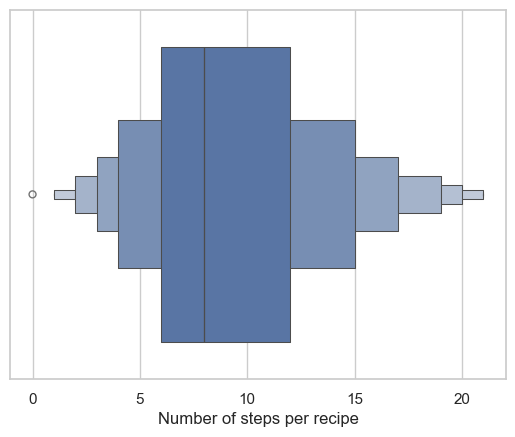

In [34]:
# Visualize boxen plot
sns.set(style = "whitegrid")
ax = sns.boxenplot(x = raw_recipes_df['n_steps'])
ax.set_xlabel('Number of steps per recipe')
plt.show()

In [35]:
# Check dataframe
raw_recipes_df.head().sort_values('n_steps')

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"['weeknight', 'time-to-make', 'course', 'main-...","[352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
3,alouette potatoes,59389,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...","[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11


In [36]:
# Filter for recipes with at least 1 step
raw_recipes_df = raw_recipes_df[raw_recipes_df['n_steps'] > 0]

In [37]:
# Sanity check
raw_recipes_df.head().sort_values('n_steps')

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"['weeknight', 'time-to-make', 'course', 'main-...","[352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
3,alouette potatoes,59389,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...","[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11


In [38]:
# Number of ingredients
# Calculate the first quartile, third quartile and the interquartile range
Q1 = raw_recipes_df['n_ingredients'].quantile(0.25)
Q3 = raw_recipes_df['n_ingredients'].quantile(0.75)
IQR = Q3 - Q1

# Calculate the maximum value and minimum values according to the Tukey rule
max_value = Q3 + 1.5 * IQR
min_value = Q1 - 1.5 * IQR

# Filter the data for values that are greater than max_value or less than min_value
nsteps_outliers = raw_recipes_df[(raw_recipes_df['n_ingredients'] > max_value) | (raw_recipes_df['n_ingredients'] < min_value)]
nsteps_outliers.sort_values('n_ingredients')

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
95755,granola extreme,43916,45,27443,2002-10-22,"['60-minutes-or-less', 'time-to-make', 'course...","[105.0, 10.0, 10.0, 2.0, 5.0, 5.0, 3.0]",9,"[""preheat oven 300' degrees"", 'spray 2 baking ...","wholesome snack, great topping for vanilla yogurt","['oatmeal', 'wheat flakes', 'buckwheat flakes'...",19
137311,mocha mini bread loaves,349861,40,1109972,2009-01-14,"['60-minutes-or-less', 'time-to-make', 'course...","[268.4, 12.0, 75.0, 12.0, 14.0, 11.0, 14.0]",7,"['preheat oven to 350 degrees', 'combine dry i...",this is adapted from camilla saulsbury's muffi...,"['whole wheat flour', 'quick-cooking oats', 't...",19
68576,curried meatballs,315007,35,331557,2008-07-22,"['curries', '60-minutes-or-less', 'time-to-mak...","[414.4, 36.0, 21.0, 32.0, 59.0, 34.0, 6.0]",8,['heat oil over medium heat and stir-fry the o...,i was given this recipe by a co-worker of mine...,"['olive oil', 'onions', 'cinnamon stick', 'wat...",19
214382,tofu spinach calzones vegan or vegetarian,97154,35,37584,2004-08-06,"['60-minutes-or-less', 'time-to-make', 'course...","[346.1, 6.0, 8.0, 14.0, 21.0, 3.0, 21.0]",17,['mix water with yeast and sugar in a large mi...,these are great and vegan or vegetarian (see s...,"['warm water', 'yeast', 'sugar', 'salt', 'flou...",19
68671,curried rice and fruit salad,63805,65,37779,2003-06-05,"['weeknight', 'time-to-make', 'course', 'main-...","[379.1, 11.0, 86.0, 16.0, 12.0, 14.0, 24.0]",18,"['wash rice until water runs clear', 'drain we...",this rice salad has exotic flavors that make a...,"['basmati rice', 'peanut oil', 'green onion', ...",19
...,...,...,...,...,...,...,...,...,...,...,...,...
105723,hillbilly bean soup,11737,255,10404,2001-09-18,"['weeknight', 'time-to-make', 'course', 'main-...","[323.0, 2.0, 254.0, 1.0, 8.0, 1.0, 27.0]",6,"['boil the drained , soaked beans with the wat...",great soup for a fall or winters dinner. serve...,"['7 bean mix', 'water', 'ham bone', 'bay leaf'...",35
203614,sunday supper taco salad bowls tacos,502219,240,695000,2013-06-23,"['time-to-make', 'course', 'cuisine', 'prepara...","[10687.7, 1784.0, 49.0, 67.0, 59.0, 802.0, 26.0]",6,['heat vegetable oil to 350f submerge tortilla...,being served again at the free sunday supper o...,"['flour tortillas', 'ground beef', 'vegetable ...",37
18352,basic fried rice with variations,248707,55,305531,2007-08-25,"['60-minutes-or-less', 'time-to-make', 'course...","[793.3, 22.0, 8.0, 23.0, 37.0, 13.0, 48.0]",16,"['dice or shred meat and vegetables', 'heat oi...",another recipe that i acquired from a chinese ...,"['brown rice', 'green onions', 'oil', 'soy sau...",38
116744,kato s garage style tomato sauce meatba...,113677,270,128473,2005-03-18,"['time-to-make', 'course', 'main-ingredient', ...","[412.8, 36.0, 61.0, 47.0, 46.0, 38.0, 8.0]",9,"['spicy tomatoe & vegetable sauce', 'in a larg...",this is our favourite spagetti dinner...we mak...,"['sweet onion', 'garlic cloves', 'green pepper...",39


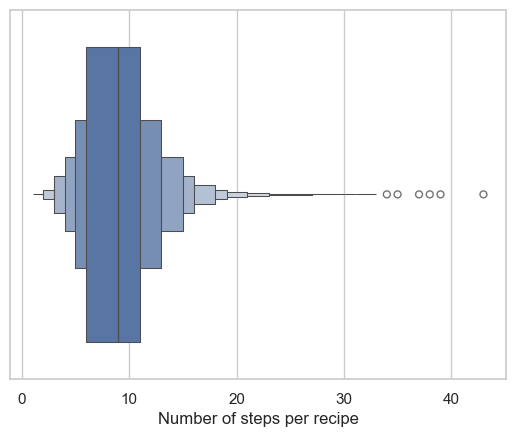

In [39]:
# Visualize boxen plot
sns.set(style = "whitegrid")
ax = sns.boxenplot(x = raw_recipes_df['n_ingredients'])
ax.set_xlabel('Number of steps per recipe')
plt.show()

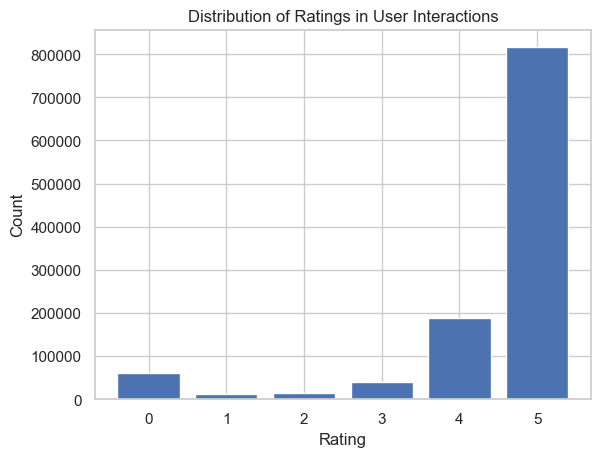

In [40]:
# Distribution of ratings

rating_counts = raw_users_df['rating'].value_counts().sort_index()
ratings = rating_counts.index
counts = rating_counts.values

plt.bar(ratings, counts)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Distribution of Ratings in User Interactions')

plt.show()

###  Zero Ratings <a class="anchor" id="threefive"></a>

In [41]:
# Keep rows that have ratings between 1 and 5
raw_users_df = raw_users_df[raw_users_df['rating'] != 0]
raw_users_df.sort_values('rating')

,user_id,recipe_id,date,rating,review
704658,1762248,428870,2013-09-10,1,These were so awful that my husband threw them...
305820,856238,213319,2008-06-07,1,"There are no stars for less than ""one"". Not g..."
305823,1263812,213319,2009-07-02,1,"Yuck! While it's palatable, it's not fudge-li..."
305824,538920,213319,2009-08-07,1,Some things just should simply not be made low...
822728,4395,4829,2001-01-10,1,I believe there is a mistake in the amount of ...
...,...,...,...,...,...
428408,431813,171157,2007-06-27,5,Wow! This far exceeded my expectations. The ...
428409,546894,171157,2007-07-27,5,I have made this several times for guests and ...
428410,819967,171157,2009-05-19,5,"Amazing recipe, this will be my standard recip..."
428365,110433,22149,2007-05-13,5,This was so juicy and had just a little kick t...


##  Data Preprocessing <a class="anchor" id="four"></a>

In [42]:
# View recipes dataset
raw_recipes_df.head()

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13
3,alouette potatoes,59389,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...","[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"['weeknight', 'time-to-make', 'course', 'main-...","[352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8


In [43]:
# View user interactions dataset
raw_users_df.head()

,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall..."
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...
3,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...
4,57222,85009,2011-10-01,5,"Made the cheddar bacon topping, adding a sprin..."


The 'date' column in the user interactions dataset can also be separated into month and year columns. In the upcoming section, we will carry out these data transformations to further explore and understand the dataset.

### Feature Engineering <a class="anchor" id="fourone"></a>

####  Nutritional Values <a class="anchor" id="fouroneone"></a>

In [44]:
# Split the values in the 'nutrition' column into separate columns
nutrition_columns = ['calories', 'total_fat', 'sugar', 'sodium', 'protein', 'saturated_fat', 'carbohydrates']

for column in nutrition_columns:
    raw_recipes_df[column] = raw_recipes_df['nutrition'].apply(lambda x: eval(x)[nutrition_columns.index(column)])

# Drop the original 'nutrition' column
raw_recipes_df.drop('nutrition', axis=1, inplace=True)

In [45]:
# Sanity check
raw_recipes_df.head()

,name,id,minutes,contributor_id,submitted,tags,n_steps,steps,description,ingredients,n_ingredients,calories,total_fat,sugar,sodium,protein,saturated_fat,carbohydrates
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7,51.5,0.0,13.0,0.0,2.0,0.0,4.0
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6,173.4,18.0,0.0,17.0,22.0,35.0,1.0
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13,269.8,22.0,32.0,48.0,39.0,27.0,5.0
3,alouette potatoes,59389,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11,368.1,17.0,10.0,2.0,14.0,8.0,20.0
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"['weeknight', 'time-to-make', 'course', 'main-...",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8,352.9,1.0,337.0,23.0,3.0,0.0,28.0


In [46]:
# Check datatypes of new columns
raw_recipes_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 216818 entries, 0 to 231636
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   name            216818 non-null  object        
 1   id              216818 non-null  object        
 2   minutes         216818 non-null  int64         
 3   contributor_id  216818 non-null  object        
 4   submitted       216818 non-null  datetime64[ns]
 5   tags            216818 non-null  object        
 6   n_steps         216818 non-null  int64         
 7   steps           216818 non-null  object        
 8   description     216818 non-null  object        
 9   ingredients     216818 non-null  object        
 10  n_ingredients   216818 non-null  int64         
 11  calories        216818 non-null  float64       
 12  total_fat       216818 non-null  float64       
 13  sugar           216818 non-null  float64       
 14  sodium          216818 non-null  float64 

#### Time Components <a class="anchor" id="fouronetwo"></a>

In [47]:
# View date column name
raw_recipes_df.columns

Index(['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags',
       'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients',
       'calories', 'total_fat', 'sugar', 'sodium', 'protein', 'saturated_fat',
       'carbohydrates'],
      dtype='object')

In [48]:
# Define the month abbreviation mapping
month_mapping = {
    1: 'Jan',
    2: 'Feb',
    3: 'Mar',
    4: 'Apr',
    5: 'May',
    6: 'Jun',
    7: 'Jul',
    8: 'Aug',
    9: 'Sep',
    10: 'Oct',
    11: 'Nov',
    12: 'Dec'
}

# Store month and year separately
raw_recipes_df['submitted_month'] = raw_recipes_df['submitted'].dt.month.map(month_mapping)
raw_recipes_df['submitted_year'] = raw_recipes_df['submitted'].dt.year

# Sanity check
raw_recipes_df.head()

,name,id,minutes,contributor_id,submitted,tags,n_steps,steps,description,ingredients,n_ingredients,calories,total_fat,sugar,sodium,protein,saturated_fat,carbohydrates,submitted_month,submitted_year
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7,51.5,0.0,13.0,0.0,2.0,0.0,4.0,Sep,2005
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6,173.4,18.0,0.0,17.0,22.0,35.0,1.0,Jun,2002
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13,269.8,22.0,32.0,48.0,39.0,27.0,5.0,Feb,2005
3,alouette potatoes,59389,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11,368.1,17.0,10.0,2.0,14.0,8.0,20.0,Apr,2003
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"['weeknight', 'time-to-make', 'course', 'main-...",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8,352.9,1.0,337.0,23.0,3.0,0.0,28.0,Oct,2002


In [49]:
# View date column name
raw_users_df.columns

Index(['user_id', 'recipe_id', 'date', 'rating', 'review'], dtype='object')

In [50]:
# Store month and year separately
raw_users_df['review_month'] = raw_users_df['date'].dt.month.map(month_mapping)
raw_users_df['review_year'] = raw_users_df['date'].dt.year

# Sanity check
raw_users_df.head()

,user_id,recipe_id,date,rating,review,review_month,review_year
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...,Feb,2003
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall...",Dec,2011
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...,Dec,2002
3,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...,Feb,2010
4,57222,85009,2011-10-01,5,"Made the cheddar bacon topping, adding a sprin...",Oct,2011


#### Dietary Preference <a class="anchor" id="fouronethree"></a>

In [51]:
# Create 5 new features
raw_recipes_df['dairy-free'] = raw_recipes_df['tags'].apply(lambda x: 1 if 'dairy-free' in x else 0)
raw_recipes_df['gluten-free'] = raw_recipes_df['tags'].apply(lambda x: 1 if 'gluten-free' in x else 0)
raw_recipes_df['low-carb'] = raw_recipes_df['tags'].apply(lambda x: 1 if 'low-carb' in x else 0)
raw_recipes_df['vegan'] = raw_recipes_df['tags'].apply(lambda x: 1 if 'vegan' in x else 0)
raw_recipes_df['vegetarian'] = raw_recipes_df['tags'].apply(lambda x: 1 if 'vegetarian' in x else 0)

In [52]:
# Sanity check
raw_recipes_df.sample(5)

,name,id,minutes,contributor_id,submitted,tags,n_steps,steps,description,ingredients,...,protein,saturated_fat,carbohydrates,submitted_month,submitted_year,dairy-free,gluten-free,low-carb,vegan,vegetarian
45052,chicken paprikash soup with spaetzle,456700,55,255344,2011-05-20,"['60-minutes-or-less', 'time-to-make', 'course...",15,"['in a 3 quart pot , melt the butter', 'add on...",i cannot say enough about how heavenly this ta...,"['butter', 'onion', 'garlic cloves', 'paprika'...",...,25.0,60.0,10.0,May,2011,0,0,0,0,0
55392,cocoa rice krispies treats with peanut butter ...,109838,10,166294,2005-01-28,"['15-minutes-or-less', 'time-to-make', 'course...",7,['melt the butter and marshmallows in the micr...,my son had a friend over to play today so i wa...,"['cocoa krispies cereal', 'butter', 'mini mars...",...,5.0,13.0,8.0,Jan,2005,0,0,0,0,0
183472,seashells nuts and bolts,205941,75,293605,2007-01-17,"['time-to-make', 'course', 'cuisine', 'prepara...",8,"['preheat oven to 250f', 'in large roasting pa...","everybody loves my nuts n bolts, been asking f...","['shreddies cereal', 'cheerios toasted oat cer...",...,22.0,40.0,15.0,Jan,2007,0,0,0,0,0
44933,chicken noodle soup with fresh herbs,323336,75,423539,2008-09-04,"['time-to-make', 'course', 'main-ingredient', ...",6,"['in a large skillet over medium heat , cook o...",what could be more comforting than a big pot o...,"['olive oil', 'onion', 'celery', 'carrots', 'f...",...,95.0,18.0,18.0,Sep,2008,0,0,1,0,0
228366,ww 1 point cheese soup,50459,50,41480,2003-01-08,"['60-minutes-or-less', 'time-to-make', 'course...",4,"['in a saucepan add vegetables , chicken broth...",easy cheesy soup (1 cup = 1ww point),"['california-blend frozen vegetables', 'chicke...",...,16.0,11.0,1.0,Jan,2003,0,0,0,0,0


In [53]:
# Another sanity check for newly-added columns
raw_recipes_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 216818 entries, 0 to 231636
Data columns (total 25 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   name             216818 non-null  object        
 1   id               216818 non-null  object        
 2   minutes          216818 non-null  int64         
 3   contributor_id   216818 non-null  object        
 4   submitted        216818 non-null  datetime64[ns]
 5   tags             216818 non-null  object        
 6   n_steps          216818 non-null  int64         
 7   steps            216818 non-null  object        
 8   description      216818 non-null  object        
 9   ingredients      216818 non-null  object        
 10  n_ingredients    216818 non-null  int64         
 11  calories         216818 non-null  float64       
 12  total_fat        216818 non-null  float64       
 13  sugar            216818 non-null  float64       
 14  sodium           216818 n

In [54]:
# View the column names
raw_users_df.columns

Index(['user_id', 'recipe_id', 'date', 'rating', 'review', 'review_month',
       'review_year'],
      dtype='object')

In [55]:
# Create a new df that contains the recipe_id and rating only
user_rating = raw_users_df[['recipe_id', 'rating']].copy()
user_rating

,recipe_id,rating
0,40893,4
1,40893,5
2,44394,4
3,85009,5
4,85009,5
...,...,...
1132360,82303,5
1132363,386618,5
1132364,78003,5
1132365,78003,4


In [56]:
# Group by recipe and take the count and the average rating
user_rating = user_rating.groupby(['recipe_id'])['rating'].agg(['mean','count'])
user_rating.reset_index(inplace=True)

# View table
user_rating.head()

,recipe_id,mean,count
0,100,3.000000,2
1,10000,3.000000,1
2,100000,4.708333,24
3,100001,4.666667,3
4,100002,4.000000,1


In [57]:
# Rename columns 
user_rating.rename(columns={'mean':'average_rating','count':'votes'},inplace=True)

# View table
user_rating

,recipe_id,average_rating,votes
0,100,3.000000,2
1,10000,3.000000,1
2,100000,4.708333,24
3,100001,4.666667,3
4,100002,4.000000,1
...,...,...,...
226578,99995,4.545455,11
226579,99996,5.000000,11
226580,99997,4.000000,1
226581,99998,5.000000,2


#### 4.2.2 Merge Datasets <a class="anchor" id="foutwotwo"></a>

In [58]:
# Merge ratings dataframe with recipe Dataframe
food_df = pd.merge(raw_recipes_df, user_rating, left_on='id',right_on='recipe_id')

# View table
food_df

,name,id,minutes,contributor_id,submitted,tags,n_steps,steps,description,ingredients,...,submitted_month,submitted_year,dairy-free,gluten-free,low-carb,vegan,vegetarian,recipe_id,average_rating,votes
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",...,Sep,2005,0,0,0,0,1,137739,5.000000,3
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",...,Jun,2002,0,0,0,0,0,31490,4.666667,3
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",...,Feb,2005,0,0,0,0,0,112140,4.000000,1
3,alouette potatoes,59389,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",...,Apr,2003,0,0,0,0,0,59389,4.500000,2
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"['weeknight', 'time-to-make', 'course', 'main-...",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",...,Oct,2002,0,0,0,0,1,44061,5.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212250,zydeco soup,486161,60,227978,2012-08-29,"['ham', '60-minutes-or-less', 'time-to-make', ...",7,"['heat oil in a 4-quart dutch oven', 'add cele...",this is a delicious soup that i originally fou...,"['celery', 'onion', 'green sweet pepper', 'gar...",...,Aug,2012,0,0,0,0,0,486161,5.000000,6
212251,zydeco spice mix,493372,5,1500678,2013-01-09,"['15-minutes-or-less', 'time-to-make', 'course...",1,['mix all ingredients together thoroughly'],this spice mix will make your taste buds dance!,"['paprika', 'salt', 'garlic powder', 'onion po...",...,Jan,2013,0,0,0,1,1,493372,5.000000,1
212252,zydeco ya ya deviled eggs,308080,40,37779,2008-06-07,"['60-minutes-or-less', 'time-to-make', 'course...",7,"['in a bowl , combine the mashed yolks and may...","deviled eggs, cajun-style","['hard-cooked eggs', 'mayonnaise', 'dijon must...",...,Jun,2008,0,0,0,0,0,308080,5.000000,5
212253,cookies by design cookies on a stick,298512,29,506822,2008-04-15,"['30-minutes-or-less', 'time-to-make', 'course...",9,['place melted butter in a large mixing bowl a...,"i've heard of the 'cookies by design' company,...","['butter', 'eagle brand condensed milk', 'ligh...",...,Apr,2008,0,0,0,0,0,298512,1.000000,1


In [59]:
# Final sanity check
food_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212255 entries, 0 to 212254
Data columns (total 28 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   name             212255 non-null  object        
 1   id               212255 non-null  object        
 2   minutes          212255 non-null  int64         
 3   contributor_id   212255 non-null  object        
 4   submitted        212255 non-null  datetime64[ns]
 5   tags             212255 non-null  object        
 6   n_steps          212255 non-null  int64         
 7   steps            212255 non-null  object        
 8   description      212255 non-null  object        
 9   ingredients      212255 non-null  object        
 10  n_ingredients    212255 non-null  int64         
 11  calories         212255 non-null  float64       
 12  total_fat        212255 non-null  float64       
 13  sugar            212255 non-null  float64       
 14  sodium           212

#### Saving the data

In [60]:
# Save the clean datasets

# Individual ones for EDA
raw_recipes_df.to_csv("clean_recipes.csv")
raw_users_df.to_csv("clean_interactions.csv")
# Merged for modelling
food_df.to_csv("food.csv")